# Notebook 03 - Neural Network Design

This notebook prepares the inputs in Spark, measures two simple baselines and then builds the network in four phases, changing one thing per phase. Phases 1 to 3 change the network and phase 4 changes how the distance is scaled. Every model is trained once and always with the same seed, so two trainings differ only in what was changed on purpose. Everything here is measured on the validation split of the original data (L0). The test split is kept for notebook 04.

### Step 1 - Import Libraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"          
import pyspark                                    
from pyspark.sql import SparkSession              
from pyspark.sql import functions as F            
print("PySpark: %s" % pyspark.__version__)        
import tensorflow as tf                           
import keras                                      
print("Tensorflow/Keras: %s / %s" % (tf.__version__, keras.__version__))   
from keras.models import Sequential, Model        
from keras import Input                           
from keras.layers import Dense, Dropout, Embedding, Concatenate   
from keras.optimizers import Adam                
from keras.callbacks import EarlyStopping         
import pandas as pd                              
print("pandas: %s" % pd.__version__)              
import numpy as np                                
print("numpy: %s" % np.__version__)               
import matplotlib.pyplot as plt                   
import json                                      
import time                                     

PySpark: 4.2.0


Tensorflow/Keras: 2.21.0 / 3.15.1
pandas: 2.3.3
numpy: 2.5.3


In [1]:
def jupyter_settings():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "savefig.bbox": "tight",
        "savefig.dpi": 120,
    })
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.float_format", "{:,.2f}".format)

jupyter_settings()

NameError: name 'plt' is not defined

### Step 2 - Settings and Spark Session

Spark runs with 2 cores and 2 GB here, because TensorFlow needs the rest of the memory once Spark stops.

In [2]:
SEED = 1234                                               
LEVELS = ["L0", "D1", "D0", "T15"]
SCALERS = ["none", "standard", "minmax", "robust", "log"] 

spark = (SparkSession.builder
         .master("local[2]")                              
         .appName("ca1-03-nn-design")
         .config("spark.driver.memory", "2g")
         .config("spark.sql.session.timeZone", "UTC")
         .config("spark.local.dir", os.path.expanduser("~/spark-tmp"))
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")



LEVELS_OUT = "hdfs://localhost:9000/ca1/levels"
NN_DIR = os.path.expanduser("~/ca1/data/nn")               
RESULTS = os.path.expanduser("~/ca1/results")
FIGURES = os.path.expanduser("~/ca1/figures")
for folder in [NN_DIR, RESULTS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/08 17:56:14 WARN Utils: Your hostname, BDSP, resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/10/08 17:56:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/08 17:56:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/08 17:56:16 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


### Step 3 - Preparing the Inputs in Spark

For each level Spark builds the inputs of the network.

- The pickup hour becomes a position on a clock face (sine and cosine), so 23:59 and 00:00 end up close to each other.
- The day of week becomes a number from 0 (Sunday) to 6.
- The distance is saved in five versions, one per scaler, so phase 4 can compare them without going back to Spark.

| Scaler | Formula | What it does to the distance |
|---|---|---|
| `none` | miles as recorded | from 0 to the longest trip, most trips below 3 |
| `standard` | (x - mean) / std | mean 0 and standard deviation 1 |
| `minmax` | (x - min) / (max - min) | between 0 and 1, set by the shortest and the longest trip |
| `robust` | (x - median) / IQR | built on the middle half of the trips, so long trips weigh less |
| `log` | log(1 + x), then standard | shrinks the long trips before scaling |

`standard`, `minmax` and `robust` only move and stretch the distance, so the first layer of the network could undo any of them, and a difference between them comes from how easily Adam finds the weights. `log` is the only one that changes the shape of the distance.

Every statistic comes from the training split of that level only, so nothing from validation or test reaches the inputs (Kapoor and Narayanan, 2023). The extracts are saved on the local disk, where pandas and TensorFlow read them.

In [3]:
stats_rows = []
for name in LEVELS:
    df = spark.read.parquet(f"{LEVELS_OUT}/train/{name}")         # the 20% of the sample written in notebook 02

    # Hour of the pickup as a position on a clock face
    pickup = df["tpep_pickup_datetime"]
    hour = F.hour(pickup) + F.minute(pickup) / 60                  # hour of day as a decimal, 14:30 becomes 14.5
    df = (df.withColumn("hour_sin", F.sin(2 * np.pi * hour / 24))
            .withColumn("hour_cos", F.cos(2 * np.pi * hour / 24))
            .withColumn("dow", F.dayofweek(pickup) - 1))           # Spark counts Sunday as 1, so 0 = Sunday

    # Statistics of the distance/ from the training split only
    s = (df.filter(df["split"] == "train")
           .agg(F.mean("trip_distance").alias("mean"),
                F.stddev("trip_distance").alias("std"),
                F.min("trip_distance").alias("min"),
                F.max("trip_distance").alias("max"),
                F.percentile_approx("trip_distance", [0.25, 0.5, 0.75], 10000).alias("quartiles"),
                F.mean(F.log1p("trip_distance")).alias("log_mean"),
                F.stddev(F.log1p("trip_distance")).alias("log_std"))
           .first())
    q1, median, q3 = s["quartiles"]

    # distance in the five versions compared in phase 4
    dist = df["trip_distance"]
    df = (df.withColumn("dist_none", dist)                                               # miles, as recorded
            .withColumn("dist_standard", (dist - s["mean"]) / s["std"])                  # mean 0, standard deviation 1
            .withColumn("dist_minmax", (dist - s["min"]) / (s["max"] - s["min"]))        # between 0 and 1
            .withColumn("dist_robust", (dist - median) / (q3 - q1))                      # median 0, middle half of the trips within 1
            .withColumn("dist_log", (F.log1p(dist) - s["log_mean"]) / s["log_std"]))     # log first, then standard

    df = df.select("trip_id", "split", *[f"dist_{sc}" for sc in SCALERS], "hour_sin", "hour_cos", "dow",
                   "PULocationID", "DOLocationID", "duration_s_true")
    df.write.mode("overwrite").parquet(f"file://{NN_DIR}/{name}")
    stats_rows.append({"level": name, "mean": s["mean"], "std": s["std"], "min": s["min"], "max": s["max"],
                       "q1": q1, "median": median, "q3": q3})
    print(name)
    df.groupBy("split").count().orderBy("split").show()   

spark.stop()                                               

dist_stats = pd.DataFrame(stats_rows).set_index("level")
dist_stats.to_csv(f"{RESULTS}/03_distance_stats.csv")
dist_stats                                                 

L0


+----------+-------+
|     split|  count|
+----------+-------+
|      test| 353946|
|     train|1152583|
|validation| 335132|
+----------+-------+



D1


+----------+-------+
|     split|  count|
+----------+-------+
|      test| 353946|
|     train|1152583|
|validation| 335132|
+----------+-------+



D0


+----------+-------+
|     split|  count|
+----------+-------+
|      test| 353946|
|     train|1152583|
|validation| 335132|
+----------+-------+



T15


+----------+-------+
|     split|  count|
+----------+-------+
|      test| 353946|
|     train|1152583|
|validation| 335132|
+----------+-------+



,mean,std,min,max,q1,median,q3
level,,,,,,,
L0,3.21,4.14,0.01,67.49,1.03,1.70,3.15
D1,3.21,4.14,0.00,67.50,1.00,1.70,3.20
D0,3.24,4.14,0.00,67.00,1.00,2.00,3.00
T15,3.21,4.14,0.01,67.49,1.03,1.70,3.15


The four levels have the same counts, 1,152,583 training trips, 335,132 validation trips and 353,946 test trips. Thus, the 20% sample has the same trips at every level. The distance statistics change little between the levels, and the mean stays between 3.21 and 3.24 miles.

### Step 4 - Training Settings and Data

The network predicts the duration in blocks of 10 minutes (`Y_SCALE`), because small target values keep the training stable, and the error is always measured back in seconds. Early stopping ends the training after 5 epochs without improvement on validation and keeps the best epoch. Op determinism makes TensorFlow give exactly the same result for the same seed.

In [4]:
Y_SCALE = 600.0                                           # the network predicts in 10 minutes blocks 
BATCH = 1024                                              # trips per update of the weights
EPOCHS = 100                                              # upper limit, early stopping decides the real number
PATIENCE = 5                                              # epochs without improvement on validation before stopping
tf.config.experimental.enable_op_determinism()            # same seed, same result

def load_level(name):
    # one extract from Step 3 of notebook 03, split into train, validation and test
    data = pd.read_parquet(f"{NN_DIR}/{name}").sort_values("trip_id")       # same row order at every level
    return {s: data[data["split"] == s] for s in ["train", "validation", "test"]}

data_l0 = load_level("L0")
{s: len(d) for s, d in data_l0.items()}                    # trips in each split

{'train': 1152583, 'validation': 335132, 'test': 353946}

### Step 5 - What Each Scaler Does to the Distance

Before training anything, the five versions of the distance are compared on the training split.

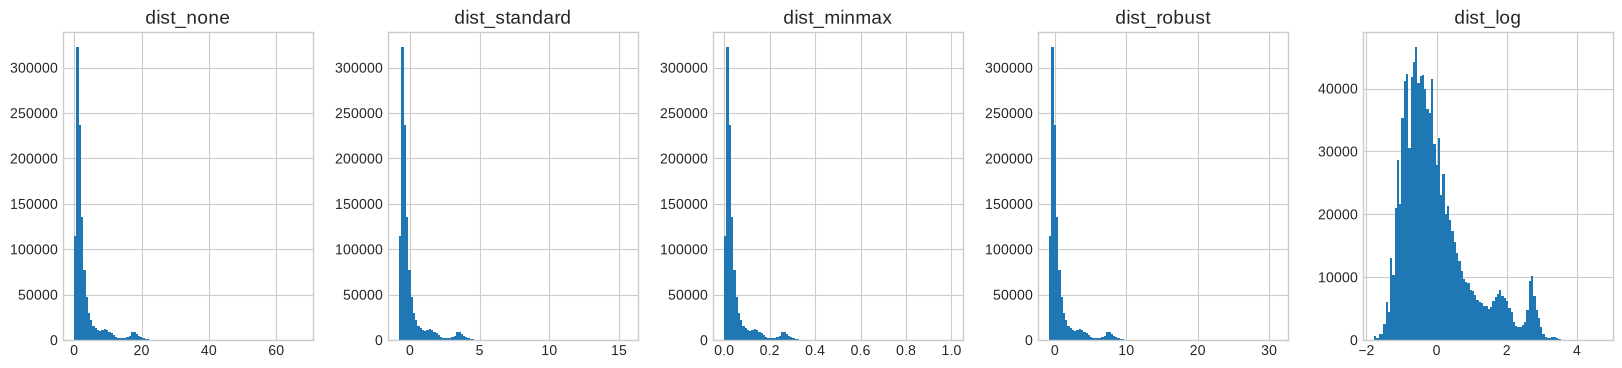

,count,mean,std,min,25%,50%,75%,max
dist_none,"1,152,583.00",3.21,4.14,0.01,1.03,1.70,3.15,67.49
dist_standard,"1,152,583.00",-0.00,1.00,-0.77,-0.53,-0.37,-0.01,15.54
dist_minmax,"1,152,583.00",0.05,0.06,0.00,0.02,0.03,0.05,1.00
dist_robust,"1,152,583.00",0.71,1.95,-0.80,-0.32,0.00,0.68,31.03
dist_log,"1,152,583.00",0.00,1.00,-1.78,-0.71,-0.27,0.39,4.70


In [5]:
train_dist = data_l0["train"][[f"dist_{sc}" for sc in SCALERS]]
train_dist.hist(bins=100, layout=(1, 5), figsize=(20, 4))   # one histogram per scaler
plt.savefig(f"{FIGURES}/03_scalers_distribution.png")
plt.show()

train_dist.describe().T

`none`, `standard`, `minmax` and `robust` have the same shape, with three quarters of the trips below 3.2 miles and a long tail on the right. Only the scale of the axis changes. With `minmax`, the longest trip, 67.5 miles, has the value 1, and three quarters of the trips have a value of 0.05 or less. `log` is the only scaler that changes the shape, and its values are between −1.8 and 4.7.

### Step 6 - Baselines

Two simple references the network has to beat. The first predicts the median training duration for every trip. The second is a straight line on distance.

In [6]:
y_val = data_l0["validation"]["duration_s_true"].to_numpy()

# Baseline 1, the median training duration for every trip
median_mae = np.abs(data_l0["train"]["duration_s_true"].median() - y_val).mean()

# Baseline 2, a straight line on distance only
slope, intercept = np.polyfit(data_l0["train"]["dist_none"], data_l0["train"]["duration_s_true"], 1)
line_mae = np.abs(slope * data_l0["validation"]["dist_none"].to_numpy() + intercept - y_val).mean()

results = {"Baseline median": {"MAE (s)": median_mae},     # one entry per model, filled in step by step
           "Baseline line on distance": {"MAE (s)": line_mae}}
pd.DataFrame(results).T

,MAE (s)
Baseline median,506.32
Baseline line on distance,306.91


The median of the training split gives a validation MAE of 506.3 s, approximately 8.4 minutes. The line on distance decreases this error to 306.9 s, approximately 40% less. Thus, the distance alone explains a large part of the duration. The network must stay below 306.9 s to be worth its cost.

### Step 7 - Inputs and Network

Phase 1 gives the zone ids to the network as plain numbers, inside a `Sequential` model, which is a single stack of layers with one input. This treats zone 100 as close to zone 101, which means nothing on a map.

From phase 2 the zones go through an embedding, a table where every zone gets 8 numbers learned during training, so zones with similar trips end up with similar numbers. One table is shared by pickup and dropoff. `Sequential` only takes one input, so phases 2 and 3 use the Functional API, which lets the zones enter through their own inputs. The layers are the same, only the way they are connected changes.

Every phase has two hidden layers of 64 and 32 neurons with ReLU and one linear output, the predicted duration. The loss is the mean squared error and Adam updates the weights. `steps_per_execution=32` makes Keras run 32 batches per call instead of one, which saves time and gives exactly the same result.

`train_and_score` trains one network, prints one line with the result and returns the error in seconds, the epoch early stopping kept, the training time and the history of every epoch.

In [7]:
def make_inputs(data, phase, scaler):
    numbers = data[[f"dist_{scaler}", "hour_sin", "hour_cos"]].to_numpy("float32")   # distance in the chosen scaling, and the hour
    days = keras.utils.to_categorical(data["dow"], num_classes=7)                   # one-hot day of week, 7 switches with one on
    if phase == "P1":
        zones = data[["PULocationID", "DOLocationID"]].to_numpy("float32") / 265     # zone id as a plain number between 0 and 1
        return np.hstack([numbers, days, zones])                                     # one input with 12 numbers
    return [np.hstack([numbers, days]),                                              # 10 numbers
            data["PULocationID"].to_numpy("int32"),                                  # pickup zone id, goes to the embedding
            data["DOLocationID"].to_numpy("int32")]                                  # dropoff zone id, goes to the embedding


def build_model(phase):
    if phase == "P1":
        # Phase 1, a plain stack of layers with one input
        model = Sequential(name="MLP-P1")
        model.add(Input(shape=(12,), name="Input-Layer"))                     # 3 numbers + 7 days + 2 zone ids
        model.add(Dense(64, activation="relu", name="Hidden-Layer-1"))        # first hidden layer, 64 neurons
        model.add(Dense(32, activation="relu", name="Hidden-Layer-2"))        # second hidden layer, 32 neurons
        model.add(Dense(1, activation="linear", name="Output-Layer"))         # one number, the predicted duration
    else:
        # Phases 2 and 3, Functional API, because the zones enter through their own inputs
        numbers = Input(shape=(10,), name="Input-Numbers")                    # 3 numbers + 7 days
        pickup = Input(shape=(), dtype="int32", name="Input-Pickup-Zone")
        dropoff = Input(shape=(), dtype="int32", name="Input-Dropoff-Zone")
        zone_table = Embedding(input_dim=266, output_dim=8, name="Zone-Embedding")   # ids go up to 265, each zone gets 8 learned numbers
        x = Concatenate(name="Concatenate-Layer")([numbers, zone_table(pickup), zone_table(dropoff)])   # one table shared by pickup and dropoff
        x = Dense(64, activation="relu", name="Hidden-Layer-1")(x)
        if phase == "P3":
            x = Dropout(0.2, name="Dropout-1")(x)                             # switches off 20% of the neurons at random while training
        x = Dense(32, activation="relu", name="Hidden-Layer-2")(x)
        if phase == "P3":
            x = Dropout(0.2, name="Dropout-2")(x)
        output = Dense(1, activation="linear", name="Output-Layer")(x)
        model = Model(inputs=[numbers, pickup, dropoff], outputs=output, name=f"MLP-{phase}")

    model.compile(optimizer=Adam(learning_rate=1e-3),        # algorithm that updates the weights, Keras default learning rate
                  loss="mean_squared_error",                 # what training minimises, big errors weigh more
                  metrics=["mean_absolute_error"],           # what we read, the average error
                  steps_per_execution=32)                    # 32 batches per call instead of one, same result in less time
    return model


def train_and_score(data, phase, scaler, seed, split="validation"):
    keras.utils.set_random_seed(seed)                                         # same seed, same starting weights and same batches
    model = build_model(phase)
    y_train = data["train"]["duration_s_true"].to_numpy("float32") / Y_SCALE  # target in blocks of 10 minutes
    y_val = data["validation"]["duration_s_true"].to_numpy("float32") / Y_SCALE
    start = time.time()
    history = model.fit(make_inputs(data["train"], phase, scaler), y_train,
                        validation_data=(make_inputs(data["validation"], phase, scaler), y_val),
                        batch_size=BATCH, epochs=EPOCHS, verbose=0,
                        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)])
    pred = model.predict(make_inputs(data[split], phase, scaler), batch_size=8192, verbose=0).ravel() * Y_SCALE   # back to seconds
    result = {"MAE (s)": np.abs(pred - data[split]["duration_s_true"].to_numpy()).mean(),   # error in seconds, against the true duration
              "Best epoch": int(np.argmin(history.history["val_loss"])) + 1,                # the epoch early stopping kept
              "Minutes": (time.time() - start) / 60}
    print(f"{phase} {scaler} seed {seed} | MAE {result['MAE (s)']:.1f} s | best epoch {result['Best epoch']} | {result['Minutes']:.1f} min")
    return result, history.history


def plot_history(history, title, filename):
    curves = pd.DataFrame(history)[["mean_absolute_error", "val_mean_absolute_error"]] * Y_SCALE   # back to seconds
    curves.columns = ["Training MAE", "Validation MAE"]
    curves.plot(figsize=(12, 5), title=title, xlabel="Epoch", ylabel="MAE (seconds)")
    plt.savefig(f"{FIGURES}/{filename}")
    plt.show()

### Step 8 - Phase 1, Zones as Numbers

The first network, with the distance in `standard` scaling.

P1 standard seed 1234 | MAE 216.4 s | best epoch 53 | 4.7 min


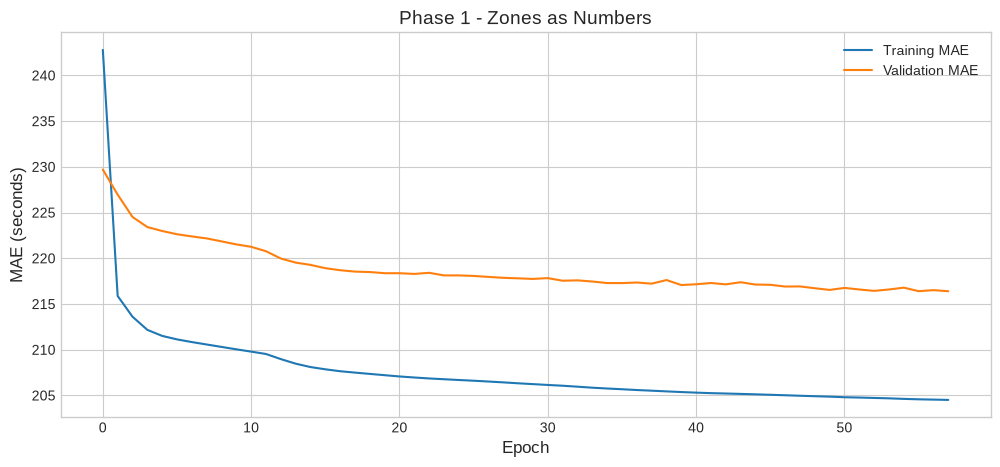

In [8]:
results["P1"], history = train_and_score(data_l0, "P1", "standard", SEED)
plot_history(history, "Phase 1 - Zones as Numbers", "03_phase1.png")

P1 got a validation MAE of 216.4 s, approximately 30% less than the line on distance. Early stopping keeps epoch 53, and the training takes 4.7 minutes. The validation MAE never increases, but at the end it is approximately 12 s above the training MAE. P1 treats zone 100 as a neighbour of zone 101, thus phase 2 replaces the ids with an embedding.

### Step 9 - Phase 2, Zone Embeddings

Only change, the zones go through the embedding.

P2 standard seed 1234 | MAE 177.5 s | best epoch 43 | 5.4 min


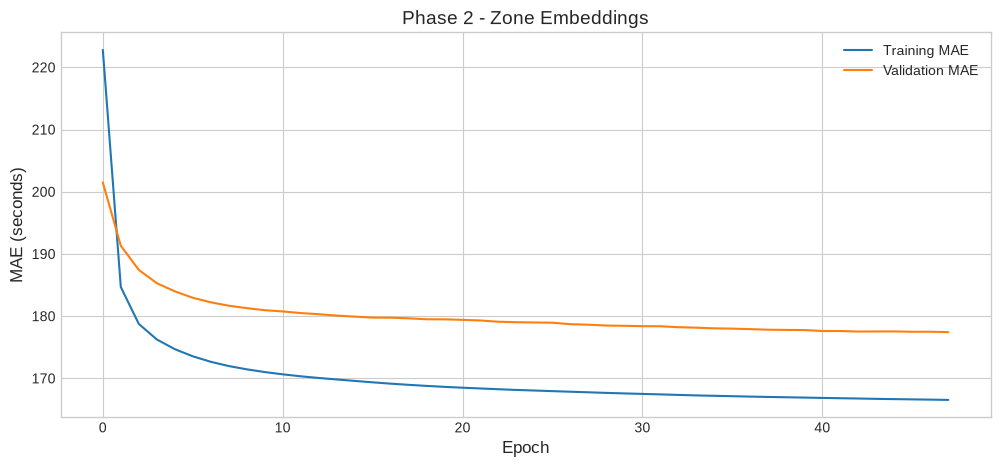

In [9]:
results["P2"], history = train_and_score(data_l0, "P2", "standard", SEED)
plot_history(history, "Phase 2 - Zone Embeddings", "03_phase2.png")

The embedding decreases the validation MAE to 177.5 s, 18% less than P1. Early stopping keeps epoch 43, and the training takes 5.4 minutes. The validation MAE never increases, it only decreases more and more slowly. At the end, the training MAE is approximately 11 s below the validation MAE. This gap can be overfitting, thus phase 3 tests dropout.

### Step 10 - Phase 3, Dropout

Only change, dropout of 0.2 after each hidden layer, which switches off 20% of the neurons at random during training to fight overfitting (Srivastava et al., 2014).

P3 standard seed 1234 | MAE 192.7 s | best epoch 7 | 2.0 min


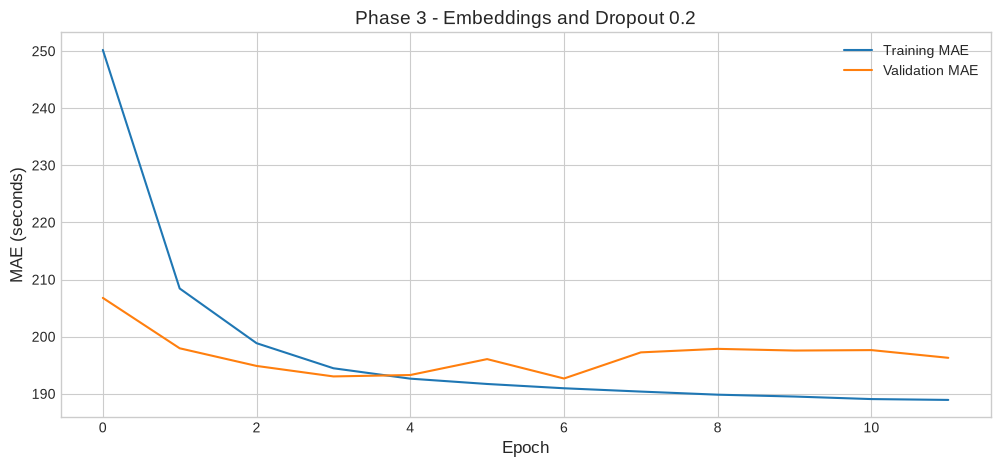

In [10]:
results["P3"], history = train_and_score(data_l0, "P3", "standard", SEED)
plot_history(history, "Phase 3 - Embeddings and Dropout 0.2", "03_phase3.png")

Dropout increases the validation MAE to 192.7 s, 15.2 s above P2. The validation MAE goes up and down after the first epochs, and early stopping keeps epoch 7. A network with 5,969 weights and 1.15 million training trips has little chance to memorise the data. P1 has the same gap without an embedding, thus the gap probably comes from the change between the training months and the validation month. For this reason, dropout only removes capacity from the network, and P2 stays.

### Step 11 - Phase Results

The phase with the lowest validation error is the network used from here on.

In [11]:
phases = pd.DataFrame(results).T.rename_axis("Model")      # one row per model
phases.to_csv(f"{RESULTS}/03_phases.csv")

BEST = phases.loc[["P1", "P2", "P3"], "MAE (s)"].idxmin()  # the phase with the lowest validation error
print("Best phase:", BEST)
phases

Best phase: P2


,MAE (s),Best epoch,Minutes
Model,,,
Baseline median,506.32,NaN,NaN
Baseline line on distance,306.91,NaN,NaN
P1,216.44,53.00,4.70
P2,177.52,43.00,5.37
P3,192.68,7.00,2.00


P2 has the lowest validation MAE, 177.5 s, and it is the network for the next phases. It is 42% below the line on distance and 65% below the median. Each phase changes only one thing, thus each difference in the table comes from one change.

### Step 12 - Phase 4, Scaling the Distance

The best network is trained once with each of the five versions of the distance, always with the same seed. With `standard` this is exactly the best phase above, so its error has to repeat to the last decimal, which checks that the training is reproducible.

Each result is saved to `03_scalers.csv` as soon as the training ends, so if the VM stops, running the cell again continues from where it stopped.

In [12]:
SCALER_FILE = f"{RESULTS}/03_scalers.csv"                                                   # one line per training, saved as soon as it ends
runs = pd.read_csv(SCALER_FILE).to_dict("records") if os.path.exists(SCALER_FILE) else []   # trainings already done, if the VM stopped before
done = [r["Scaler"] for r in runs]

for scaler in SCALERS:
    if scaler in done:
        continue                                                                             # already trained in an earlier run
    result, _ = train_and_score(data_l0, BEST, scaler, SEED)
    runs.append({"Scaler": scaler, **result})                                                # adds MAE, best epoch and minutes
    pd.DataFrame(runs).to_csv(SCALER_FILE, index=False)

P2 none seed 1234 | MAE 178.0 s | best epoch 68 | 9.7 min


P2 standard seed 1234 | MAE 177.5 s | best epoch 43 | 7.0 min


P2 minmax seed 1234 | MAE 181.4 s | best epoch 37 | 3.9 min


P2 robust seed 1234 | MAE 178.6 s | best epoch 44 | 6.4 min


P2 log seed 1234 | MAE 179.1 s | best epoch 28 | 5.1 min


### Step 13 - Scaler Results

Each scaler is compared with `standard`. With one training per scaler, the normal variation of training cannot be measured here, so the rule uses a fixed margin, set before seeing the results. `standard` stays unless another scaler lowers the error by more than 1%, because a smaller change could come from the training itself and does not earn its place.

Lowest error: standard | gain over standard 0.00 s | margin 1.78 s | chosen scaler: standard


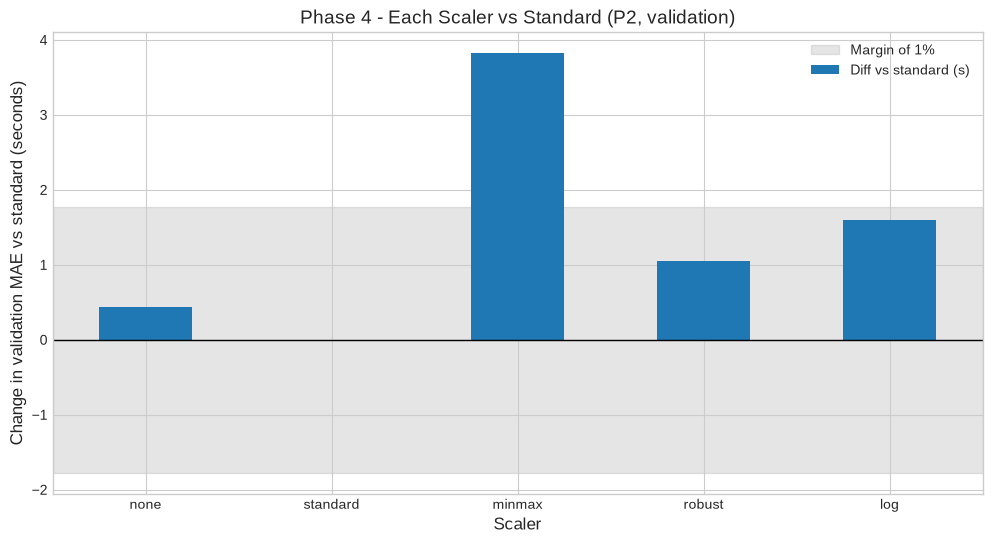

,MAE (s),Best epoch,Minutes,Diff vs standard (s)
Scaler,,,,
none,177.97,68,9.67,0.44
standard,177.52,43,6.99,0.00
minmax,181.35,37,3.87,3.83
robust,178.57,44,6.37,1.05
log,179.12,28,5.08,1.59


In [13]:
scalers = pd.DataFrame(runs).set_index("Scaler").loc[SCALERS]       # one row per scaler
scalers["Diff vs standard (s)"] = scalers["MAE (s)"] - scalers.loc["standard", "MAE (s)"]

# The rule, set before the results
MARGIN_PCT = 1.0                                                    # changes smaller than 1% of the error count as no difference
margin = scalers.loc["standard", "MAE (s)"] * MARGIN_PCT / 100
best_scaler = scalers["MAE (s)"].idxmin()
gain = scalers.loc["standard", "MAE (s)"] - scalers.loc[best_scaler, "MAE (s)"]   # how much the best scaler improves on standard
SCALER = best_scaler if gain > margin else "standard"
print(f"Lowest error: {best_scaler} | gain over standard {gain:.2f} s | margin {margin:.2f} s | chosen scaler: {SCALER}")

ax = scalers["Diff vs standard (s)"].plot(kind="bar", rot=0, figsize=(12, 6),
                                         title=f"Phase 4 - Each Scaler vs Standard ({BEST}, validation)")
ax.axhspan(-margin, margin, color="grey", alpha=0.2, zorder=0, label="Margin of 1%")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Scaler")
ax.set_ylabel("Change in validation MAE vs standard (seconds)")
ax.legend()
plt.savefig(f"{FIGURES}/03_scalers.png")
plt.show()
scalers

* `standard` has the lowest validation MAE, 177.52 s, and it stays as the scaler of the network. This error is the same as the P2 error to the last decimal, thus the training is reproducible with the same seed.
* `none` is only 0.44 s above, but it needs 68 epochs, against 43 for `standard`. `robust` and `log` are also inside the margin of 1.78 s.
* Only `minmax` is outside, with 3.83 s more, probably because it puts most distances very near zero.

### Step 14 - Freezing the Final Design

The chosen phase, the chosen scaler, the seed, the margin and the training settings are saved to a file, so notebook 04 uses exactly the same network without typing anything again.

In [14]:
frozen = {"phase": BEST, "scaler": SCALER, "seed": SEED, "margin_pct": MARGIN_PCT,
          "y_scale": Y_SCALE, "batch": BATCH, "epochs": EPOCHS, "patience": PATIENCE}
with open(f"{RESULTS}/03_final_config.json", "w") as f:
    json.dump(frozen, f, indent=2)
print(frozen)

build_model(BEST).summary()

{'phase': 'P2', 'scaler': 'standard', 'seed': 1234, 'margin_pct': 1.0, 'y_scale': 600.0, 'batch': 1024, 'epochs': 100, 'patience': 5}


Model: "MLP-P2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input-Pickup-Zone   │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-Dropoff-Zone  │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-Numbers       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Zone-Embedding      │ (None, 8)         │      2,128 │ Input-Pickup-Zon… │
│ (Embedding)         │                   │            │ Input-Dropoff-Zo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate-Layer   │ (None, 26)        │          0 │ Input-Numbers[0]… │
│ (Concatenate)       │                   │            │ Zone-Embedding[0… │
│                     │                   │            │ Zone-Embedding[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Hidden-Layer-1      │ (None, 64)        │      1,728 │ Concatenate-Laye… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Hidden-Layer-2      │ (None, 32)        │      2,080 │ Hidden-Layer-1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output-Layer        │ (None, 1)         │         33 │ Hidden-Layer-2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,969 (23.32 KB)

 Trainable params: 5,969 (23.32 KB)

 Non-trainable params: 0 (0.00 B)